# Google Trends Analysis — Disease Surveillance Keywords

Reads the raw data produced by `trends_extract.py` and produces:
- `trends_subtype_means.csv` — monthly z-score mean per sub-type per country
- `trends_timeseries.png` — 6-panel faceted time-series chart

**Prerequisites:** run `trends_extract.py` first to generate `trends_raw_data.csv`.

## 0. Imports & Configuration

In [22]:
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import numpy as np

In [13]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Update these if your files are in a different location.

RAW_DATA_CSV  = Path("trends_normalised_data.csv")    # produced by trends_extract.py
ANCHORS_CSV   = Path("trends_anchors.csv")      # produced by trends_extract.py
KEYWORDS_CSV  = Path(r"C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance"
                     r"\One_Health_Proposal_Eugenia\Datasets\Google_dataset.csv")
CSV_PATH  = r"C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Datasets"
KEYWORDS_ENCODING = "cp1252"
OUTPUT_PATH    = Path(".")

# ── Visual design ─────────────────────────────────────────────────────────────
SUBTYPE_COLOURS: dict[str, str] = {
    "Aedes":       "#E69F00",
    "Chikungunya": "#56B4E9",
    "Dengue":      "#009E73",
    "Zika":        "#F0E442",
    "Culex":       "#0072B2",
    "Usutu":       "#D55E00",
    "West Nile":   "#CC79A7",
}

SYSTEM_COLOURS: dict[str, str] = {
    "Aedes-borne disease system": "#0072B2",
    "Culex-borne disease system": "#D55E00",
}

SYSTEM_STYLES: dict[str, str] = {
    "Aedes-borne disease system": "dashed",
    "Culex-borne disease system": "solid",
}

COUNTRY_LABELS: dict[str, str] = {
    "DE": "Germany",
    "AT": "Austria",
    "CH": "Switzerland",
    "IT": "Italy",
    "ES": "Spain",
    "FR": "France",
}

# Preferred country order in the figure
COUNTRY_ORDER = ["DE", "AT", "CH", "IT", "ES", "FR"]

# Must match what was used in trends_extract.py
ANCHOR_PER_COUNTRY: dict[str, str] = {
    "DE": "Mücke",
    "AT": "Mücke",
    "CH": "Mücke",
    "IT": "Zanzara",
    "ES": "Mosquito",
    "FR": "Moustique",
}

## 1. Load Raw Data

In [7]:
# ── Load the wide-format raw CSV produced by trends_extract.py ───────────────
# Columns are named "GEO::keyword", e.g. "DE::Dengue fieber"

raw_all = pd.read_csv(RAW_DATA_CSV, index_col=0, parse_dates=True)
anchors_raw = pd.read_csv(ANCHORS_CSV, index_col=0, parse_dates=True)
print(f"Loaded {raw_all.shape[1]} keyword-country columns × {len(raw_all)} time points")
raw_all.head()

Loaded 258 keyword-country columns × 192 time points


,DE::Aedes-Mücke,DE::Aedes Mücke,DE::Tigermücke,DE::Tiger Mücke,DE::Zika Virus,DE::Zikavirus,DE::Zika-Virus,DE::Zika-Fieber,DE::Zika Fieber,DE::Denguefieber,...,FR::Moustique Culex,FR::Virus Usutu,FR::Virus d’Usutu,FR::Aedes albopictus,FR::Zika,FR::Dengue,FR::Chikungunya,FR::Culex pipiens,FR::Culex torrentium,FR::Culex modestus
time [UTC],,,,,,,,,,,,,,,,,,,,,
2010-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,33.333333,33.333333,0.0,0.0,0.0
2010-02-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,33.333333,0.000000,0.0,0.0,0.0
2010-03-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,33.333333,0.000000,0.0,0.0,0.0
2010-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,25.000000,25.000000,0.0,0.0,0.0
2010-05-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.448276,...,0.0,0.0,0.0,0.0,0.0,16.666667,16.666667,0.0,0.0,0.0


In [8]:
# ── Split wide table back into per-country DataFrames ─────────────────────────
country_data: dict[str, pd.DataFrame] = {}

for geo in COUNTRY_ORDER:
    cols = [c for c in raw_all.columns if c.startswith(f"{geo}::")]
    if not cols:
        print(f"WARNING: no columns found for {geo} — was this country fetched?")
        continue
    sub = raw_all[cols].copy()
    sub.columns = [c.split("::", 1)[1] for c in cols]   # strip the "GEO::" prefix
    country_data[geo] = sub
    print(f"  {geo}: {len(cols)} keywords")

  DE: 36 keywords
  AT: 36 keywords
  CH: 90 keywords
  IT: 25 keywords
  ES: 25 keywords
  FR: 46 keywords


## 2. Load Keyword Metadata

In [9]:
kw_df = pd.read_csv(KEYWORDS_CSV, encoding=KEYWORDS_ENCODING)
kw_df.columns = kw_df.columns.str.strip()
for col in ["Keyword", "Language", "System", "Sub-type", "Type"]:
    kw_df[col] = kw_df[col].astype(str).str.strip()

# Build {keyword: {Sub-type, System, Type}} lookup (first occurrence wins for duplicates)
meta: dict[str, dict] = (
    kw_df.drop_duplicates(subset="Keyword")
         .set_index("Keyword")[["Sub-type", "System", "Type"]]
         .to_dict(orient="index")
)

print(f"Loaded metadata for {len(meta)} unique keywords")
print("Sub-types:", sorted({v['Sub-type'] for v in meta.values()}))
print("Systems  :", sorted({v['System']   for v in meta.values()}))

Loaded metadata for 122 unique keywords
Sub-types: ['Aedes', 'Chikungunya', 'Culex', 'Dengue', 'Usutu', 'West Nile', 'Zika']
Systems  : ['Aedes-borne disease system', 'Culex-borne disease system']


## 3. Calculate monthly mean per Sub-type per Country

Each keyword is averaged within a sub-type. Could change this to weighted mean for full (non-proposal) analysis.

In [17]:
def build_subtype_means(
    country_data: dict[str, pd.DataFrame],
    meta: dict[str, dict],
) -> dict[str, dict[str, pd.Series]]:
    """
    For each country × sub-type, calculate the mean of the
    anchor-normalised Google Trends values across all keywords
    in that sub-type.

    Returns
    -------
    {geo: {subtype: pd.Series(monthly mean interest)}}
    """
    all_subtypes = sorted({v["Sub-type"] for v in meta.values()})
    result: dict[str, dict[str, pd.Series]] = {}

    for geo, df in country_data.items():
        result[geo] = {}

        for subtype in all_subtypes:
            cols = [
                kw for kw in df.columns
                if kw in meta and meta[kw]["Sub-type"] == subtype
            ]

            if not cols:
                continue

            # Mean anchor-normalised interest across keywords
            result[geo][subtype] = df[cols].mean(axis=1)

    return result


subtype_means = build_subtype_means(country_data, meta)
print("Sub-type means computed for:", list(subtype_means.keys()))

Sub-type means computed for: ['DE', 'AT', 'CH', 'IT', 'ES', 'FR']


In [36]:
anchor_series: dict[str, pd.Series] = {}

for geo in COUNTRY_ORDER:
    anchor_word = ANCHOR_PER_COUNTRY.get(geo)
    col = f"{geo}::{anchor_word}"

    if col not in anchors_raw.columns:
        print(f"WARNING: anchor column '{col}' not found in {ANCHORS_CSV}")
        continue

    anchor_series[geo] = anchors_raw[col].dropna()

    print(
        f"  {geo}: anchor '{anchor_word}' loaded "
        f"({len(anchor_series[geo])} points)"
    )

anchor_series[geo].index = pd.to_datetime(anchor_series[geo].index)

  DE: anchor 'Mücke' loaded (192 points)
  AT: anchor 'Mücke' loaded (192 points)
  CH: anchor 'Mücke' loaded (189 points)
  IT: anchor 'Zanzara' loaded (192 points)
  ES: anchor 'Mosquito' loaded (192 points)
  FR: anchor 'Moustique' loaded (192 points)


## 4. Save Sub-type Means to CSV

In [ ]:
means_frames = []
for geo, subtypes in subtype_means.items():
    for subtype, series in subtypes.items():
        means_frames.append(series.rename(f"{geo}::{subtype}"))

means_df = pd.concat(means_frames, axis=1)
means_path = OUTPUT_PATH / "trends_subtype_means.csv"
means_df.to_csv(means_path)
print(f"Saved → {means_path}")
means_df.head()

Saved → trends_subtype_means.csv


,DE::Aedes,DE::Chikungunya,DE::Culex,DE::Dengue,DE::Usutu,DE::West Nile,DE::Zika,AT::Aedes,AT::Chikungunya,AT::Culex,...,ES::Usutu,ES::West Nile,ES::Zika,FR::Aedes,FR::Chikungunya,FR::Culex,FR::Dengue,FR::Usutu,FR::West Nile,FR::Zika
time [UTC],,,,,,,,,,,,,,,,,,,,,
2010-01-01,0.0,0.540541,0.0,10.325710,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,16.666667,0.0,2.083333,0.0,0.0,0.0
2010-02-01,0.0,0.714286,0.0,18.452381,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,2.083333,0.0,0.0,0.0
2010-03-01,0.0,0.689655,0.0,26.724138,0.0,0.0,1.666667,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,2.083333,0.0,0.0,0.0
2010-04-01,0.0,0.000000,0.0,27.298851,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.250000,0.0,1.562500,0.0,0.0,0.0
2010-05-01,0.0,0.000000,0.0,25.632184,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.166667,0.0,1.041667,0.0,0.0,0.0


## 5. Quick Exploratory View

Inspect the data before plotting — useful for spotting anomalies.

In [14]:
# How many keywords per sub-type per country?
rows = []
for geo, df in country_data.items():
    for subtype in sorted({v['Sub-type'] for v in meta.values()}):
        cols = [kw for kw in df.columns if kw in meta and meta[kw]['Sub-type'] == subtype]
        rows.append({"Country": geo, "Sub-type": subtype, "n_keywords": len(cols)})

coverage = pd.DataFrame(rows).pivot(index="Sub-type", columns="Country", values="n_keywords").fillna(0).astype(int)
print("Keyword coverage per sub-type × country:")
coverage

Keyword coverage per sub-type × country:


Country,AT,CH,DE,ES,FR,IT
Sub-type,,,,,,
Aedes,6,15,6,4,7,4
Chikungunya,5,9,5,3,4,3
Culex,7,13,7,6,6,6
Dengue,6,25,6,4,16,5
Usutu,2,4,2,1,2,1
West Nile,4,11,4,3,4,3
Zika,6,13,6,4,7,3


In [15]:
# Pairwise correlation of sub-type means within each country
for geo in COUNTRY_ORDER:
    if geo not in subtype_means:
        continue
    df_tmp = pd.DataFrame(subtype_means[geo])
    print(f"\n── {COUNTRY_LABELS.get(geo, geo)} correlation matrix ──")
    display(df_tmp.corr().round(2))


── Germany correlation matrix ──


,Aedes,Chikungunya,Culex,Dengue,Usutu,West Nile,Zika
Aedes,1.00,0.30,NaN,0.01,0.11,0.27,0.01
Chikungunya,0.30,1.00,NaN,0.08,-0.05,0.04,-0.01
Culex,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dengue,0.01,0.08,NaN,1.00,-0.03,-0.04,-0.02
Usutu,0.11,-0.05,NaN,-0.03,1.00,0.47,-0.02
West Nile,0.27,0.04,NaN,-0.04,0.47,1.00,-0.04
Zika,0.01,-0.01,NaN,-0.02,-0.02,-0.04,1.00



── Austria correlation matrix ──


,Aedes,Chikungunya,Culex,Dengue,Usutu,West Nile,Zika
Aedes,1.00,0.41,-0.04,0.18,0.15,0.23,-0.06
Chikungunya,0.41,1.00,-0.02,0.12,-0.00,0.02,0.01
Culex,-0.04,-0.02,1.00,0.10,-0.02,-0.02,-0.04
Dengue,0.18,0.12,0.10,1.00,-0.04,-0.04,0.12
Usutu,0.15,-0.00,-0.02,-0.04,1.00,0.19,-0.01
West Nile,0.23,0.02,-0.02,-0.04,0.19,1.00,-0.03
Zika,-0.06,0.01,-0.04,0.12,-0.01,-0.03,1.00



── Switzerland correlation matrix ──


...

,Aedes,Chikungunya,Culex,Dengue,Usutu,West Nile,Zika
Aedes,1.00,0.08,0.24,0.06,0.00,0.30,-0.08
Chikungunya,0.08,1.00,0.11,-0.03,0.01,-0.02,-0.00
Culex,0.24,0.11,1.00,-0.04,0.06,-0.02,0.30
Dengue,0.06,-0.03,-0.04,1.00,0.07,-0.01,-0.05
Usutu,0.00,0.01,0.06,0.07,1.00,-0.01,-0.01
West Nile,0.30,-0.02,-0.02,-0.01,-0.01,1.00,-0.02
Zika,-0.08,-0.00,0.30,-0.05,-0.01,-0.02,1.00



── Spain correlation matrix ──


,Aedes,Chikungunya,Culex,Dengue,Usutu,West Nile,Zika
Aedes,1.00,0.10,-0.01,-0.38,-0.07,0.06,0.03
Chikungunya,0.10,1.00,-0.02,0.03,0.16,-0.04,0.03
Culex,-0.01,-0.02,1.00,-0.07,-0.01,0.17,-0.02
Dengue,-0.38,0.03,-0.07,1.00,-0.01,-0.09,-0.09
Usutu,-0.07,0.16,-0.01,-0.01,1.00,-0.01,-0.01
West Nile,0.06,-0.04,0.17,-0.09,-0.01,1.00,-0.03
Zika,0.03,0.03,-0.02,-0.09,-0.01,-0.03,1.00



── France correlation matrix ──


,Aedes,Chikungunya,Culex,Dengue,Usutu,West Nile,Zika
Aedes,1.00,-0.07,NaN,-0.31,NaN,0.08,-0.00
Chikungunya,-0.07,1.00,NaN,0.35,NaN,-0.05,0.02
Culex,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dengue,-0.31,0.35,NaN,1.00,NaN,-0.07,-0.01
Usutu,NaN,NaN,NaN,NaN,NaN,NaN,NaN
West Nile,0.08,-0.05,NaN,-0.07,NaN,1.00,-0.03
Zika,-0.00,0.02,NaN,-0.01,NaN,-0.03,1.00


## 6. Yearly time-series Plot — 6-Panel Facet Chart

3-month rolling average currently diasabled. Anchor graph currently enabled.

In [11]:
subtype_means = pd.read_csv("trends_subtype_means.csv", index_col=0)

Chart saved → GoogleTrends_without_zika.png


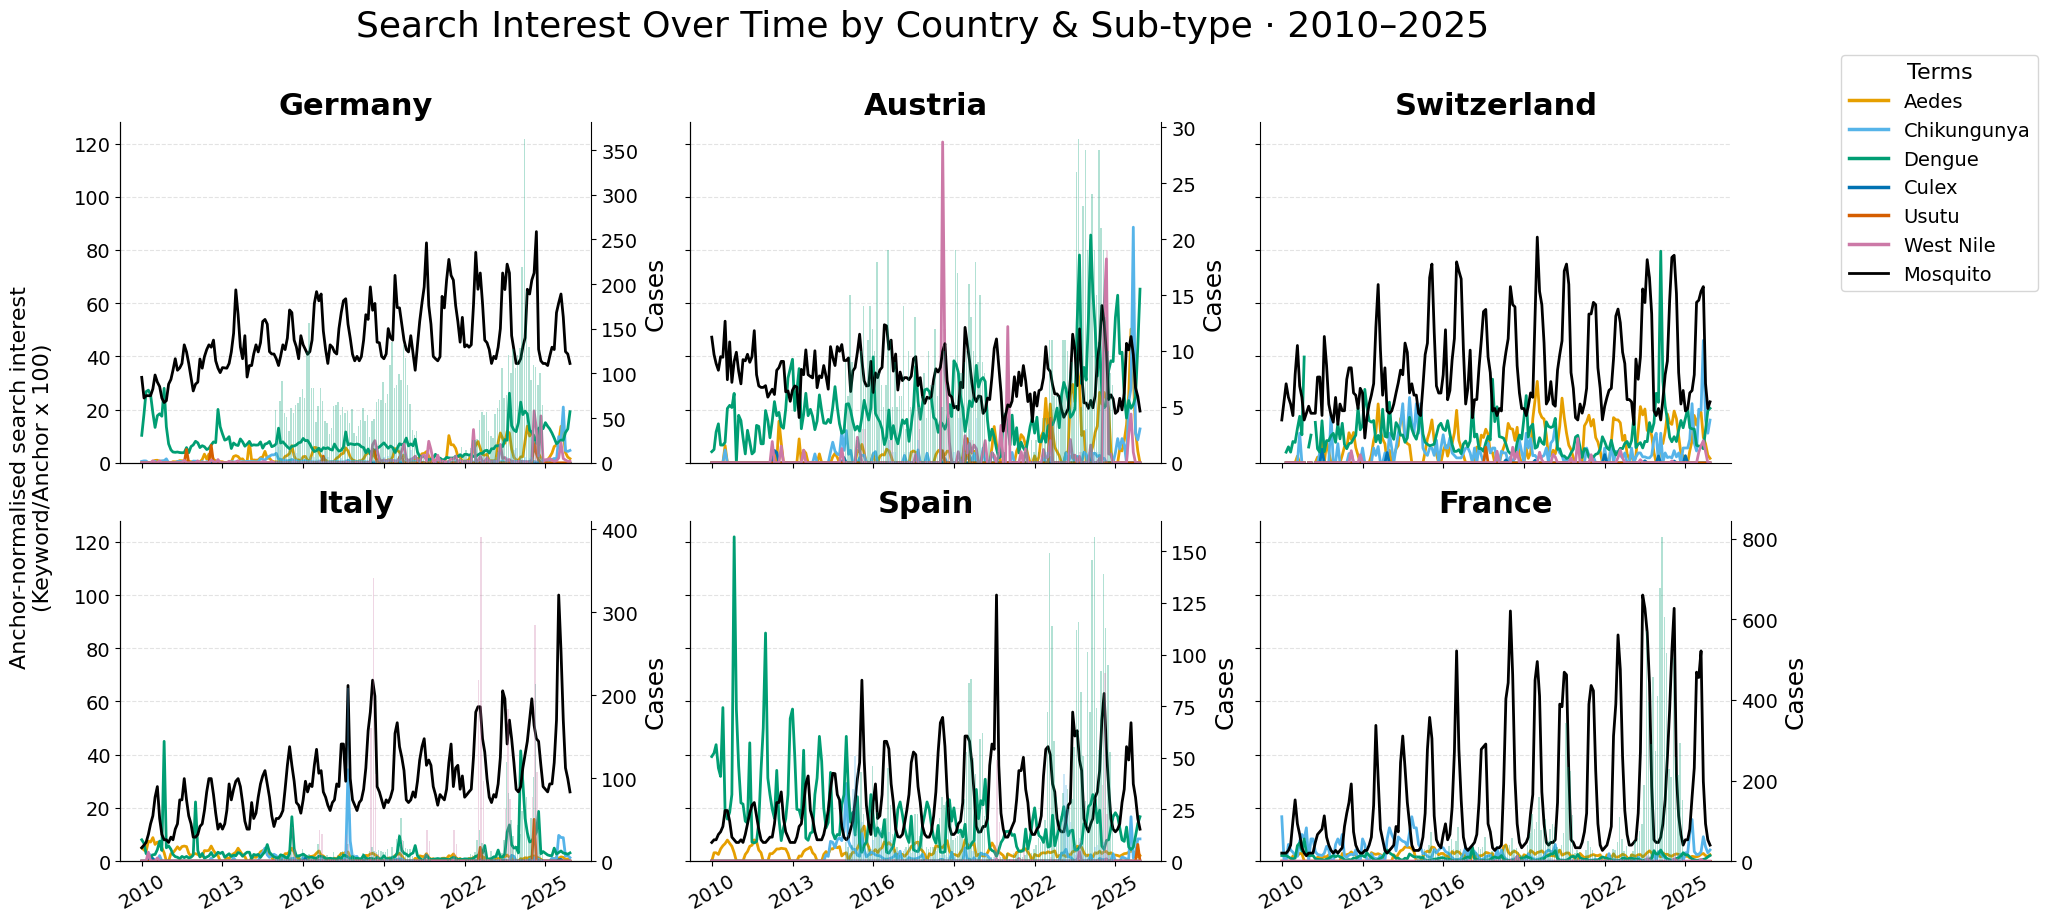

In [56]:
dengue = pd.read_csv(Path(CSV_PATH)/"ECDC_surveillance_data_Dengue.csv")
chik   = pd.read_csv(Path(CSV_PATH)/"ECDC_surveillance_data_Chikungunya_virus_disease.csv")
wnv    = pd.read_csv(Path(CSV_PATH)/"ECDC_surveillance_data_West_Nile_virus_infection.csv")
zika   = pd.read_csv(Path(CSV_PATH)/"ECDC_surveillance_data_Zika_virus_infection.csv")

def prep_ecdc(df):
    df = df.copy()
    df.columns = df.columns.str.lower().str.strip()

    # Convert Time (YYYY-MM) to datetime
    df["date"] = pd.to_datetime(df["time"], format="%Y-%m")

    # Clean numeric values
    df["numvalue"] = pd.to_numeric(df["numvalue"], errors="coerce").fillna(0)

    # Standardize names
    df = df.rename(columns={
        "regionname": "country",
        "numvalue": "cases"
    })

    return df[["country", "date", "cases"]]

dengue = prep_ecdc(dengue)
chik = prep_ecdc(chik)
wnv = prep_ecdc(wnv)
zika = prep_ecdc(zika)


def plot_timeseries(
    country_data: dict[str, pd.DataFrame],
    meta: dict[str, dict],
    anchor_series: dict[str, pd.Series] | None = None,
    save_path: Path | None = None,
) -> plt.Figure:

    subtype_to_system = {
        v["Sub-type"]: v["System"]
        for v in meta.values()
    }

    countries = [g for g in COUNTRY_ORDER if g in country_data]

    fig, axes = plt.subplots(
        2, 3,
        figsize=(18, 9),
        sharex=True,
        sharey=True,
    )

    axes_flat = axes.flatten()

    disease_lookup = {
        "Dengue": dengue,
        "Chikungunya": chik,
        "West Nile": wnv,
        "Zika": zika,
    }

    for ax, geo in zip(axes_flat, countries):

        df = country_data[geo]

        subtype_totals = subtype_means.loc[:, subtype_means.columns.str.startswith(f"{geo}::")]

        # ------------------------------------------------------------------
        # Plot search interest
        # ------------------------------------------------------------------
        for col, series in subtype_totals.items():
            
            series = series.copy()
            series.index = pd.to_datetime(series.index)
            series = series.sort_index()

            subtype = col.split("::")[1]   # ← FIX
            if subtype == "Zika":
                continue

            colour = SUBTYPE_COLOURS[subtype]

            ax.plot(
                series.index,
                series.values,
                color=colour,
                linewidth=2,
                linestyle="solid",
                label=subtype,
            )

        # ------------------------------------------------------------------
        # Anchor
        # ------------------------------------------------------------------
        if anchor_series and geo in anchor_series:

            anc = anchor_series[geo]

            ax.plot(
                anc.index,
                anc.values,
                color="black",
                linewidth=2,
                linestyle="solid",
                label="Mosquito",
            )

        # ------------------------------------------------------------------
        # ECDC case counts
        # ------------------------------------------------------------------
        disease_series = []

        for subtype, ddf in disease_lookup.items():

            if subtype == "Zika":
                continue

            country_name = COUNTRY_LABELS.get(geo, geo)
            dsub = ddf[ddf["country"] == country_name]

            if dsub.empty:
                continue

            dsub = dsub[
                (dsub["date"] >= "2015-01-01")
                & (dsub["date"] <= "2025-01-01")
            ].copy()

            if dsub.empty:
                continue

            dsub["Subtype"] = subtype
            disease_series.append(dsub)

        if disease_series:

            ax2 = ax.twinx()

            offsets = np.linspace(-10, 10, len(disease_series))

            for offset, dsub in zip(offsets, disease_series):

                subtype = dsub["Subtype"].iloc[0]

                colour = SUBTYPE_COLOURS.get(subtype, "grey")

                ax2.bar(
                    dsub["date"] + pd.to_timedelta(offset, unit="D"),
                    dsub["cases"],
                    width=20,
                    color=matplotlib.colors.to_rgba(colour, alpha=0.3),
                )

            ax2.set_ylabel("Cases", fontsize=18)
            ax2.tick_params(axis="y", labelsize=14)
            ax2.spines["top"].set_visible(False)

        # ------------------------------------------------------------------
        # Formatting
        # ------------------------------------------------------------------
        ax.set_title(
            COUNTRY_LABELS.get(geo, [geo]),
            fontsize=22,
            fontweight="bold",
        )

        ax.tick_params(axis="x", rotation=30, labelsize=14)
        ax.tick_params(axis="y", labelsize=14)

        ax.grid(axis="y", linestyle="--", alpha=0.35)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # ----------------------------------------------------------------------
    # Axis formatting
    # ----------------------------------------------------------------------
    axes_flat[0].xaxis.set_major_locator(mdates.YearLocator(3))
    axes_flat[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ymax = axes_flat[0].get_ylim()[1]

    fig.text(
        0.005,
        0.5,
        "Anchor-normalised search interest\n(Keyword/Anchor x 100)",
        rotation="vertical",
        va="center", ha="center",
        fontsize=16,
    )

    # ----------------------------------------------------------------------
    # Legends
    # ----------------------------------------------------------------------
    subtype_handles = [
        mlines.Line2D(
            [],
            [],
            color=colour,
            linewidth=2.5,
            label=subtype,
        )
        for subtype, colour in SUBTYPE_COLOURS.items()
        if subtype in subtype_to_system and subtype != "Zika"
    ]

    anchor_handle = [
        mlines.Line2D(
            [],
            [],
            color="black",
            linewidth=2,
            linestyle="solid",
            label="Mosquito",
        )
    ]

    fig.legend(
        handles=subtype_handles + anchor_handle,
        title="Terms",
        title_fontsize=16,
        prop={"size": 14},
        loc="upper left",
        bbox_to_anchor=(1.005, 0.98),
        frameon=True,
    )

    fig.suptitle(
        "Search Interest Over Time by Country & Sub-type · 2010–2025",
        fontsize=26,
        y=1.02,
    )

    plt.tight_layout(rect=[0.02, 0, 1, 1])

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Chart saved → {save_path}")

    #fix yaxis
    for ax in axes_flat[:len(countries)]:
        ax.set_ylim(bottom=0)

    return fig

fig = plot_timeseries(
    country_data,
    meta,
    anchor_series=anchor_series,
    save_path=OUTPUT_PATH / "GoogleTrends_without_zika.png",
)

plt.show()

## 7. Optional: Per-Country Deep-dive Plots

Uncomment and run for larger single-country views.

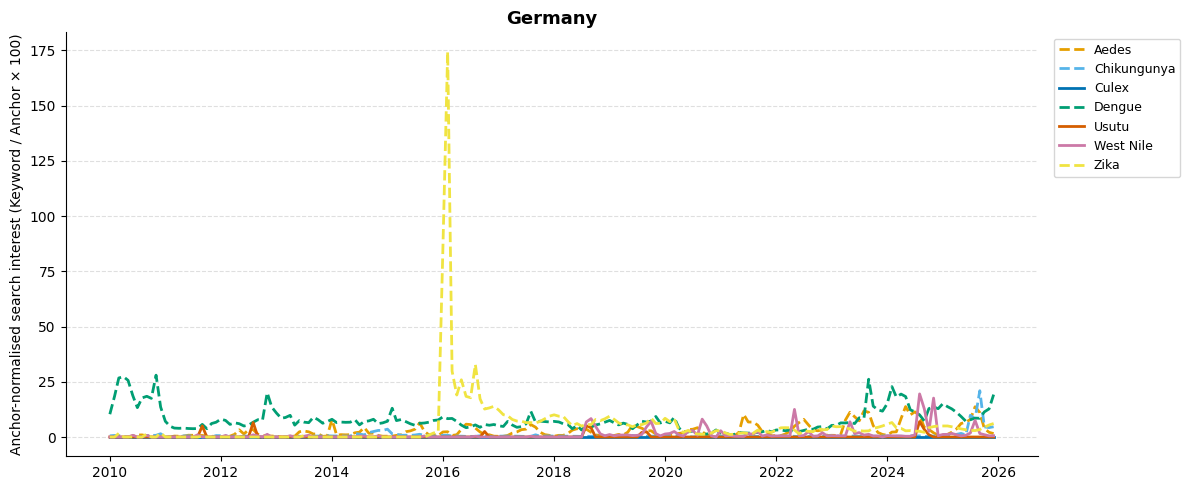

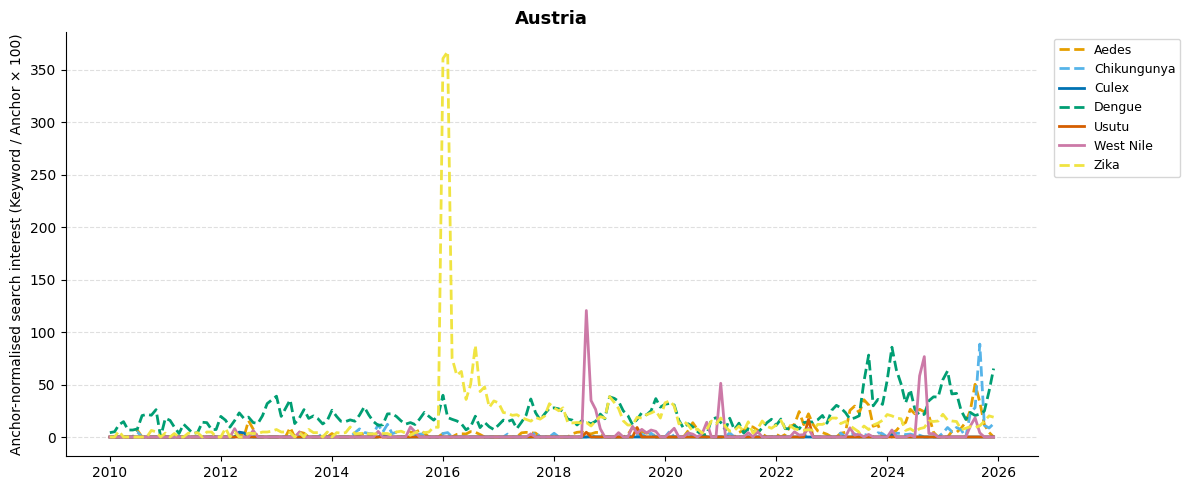

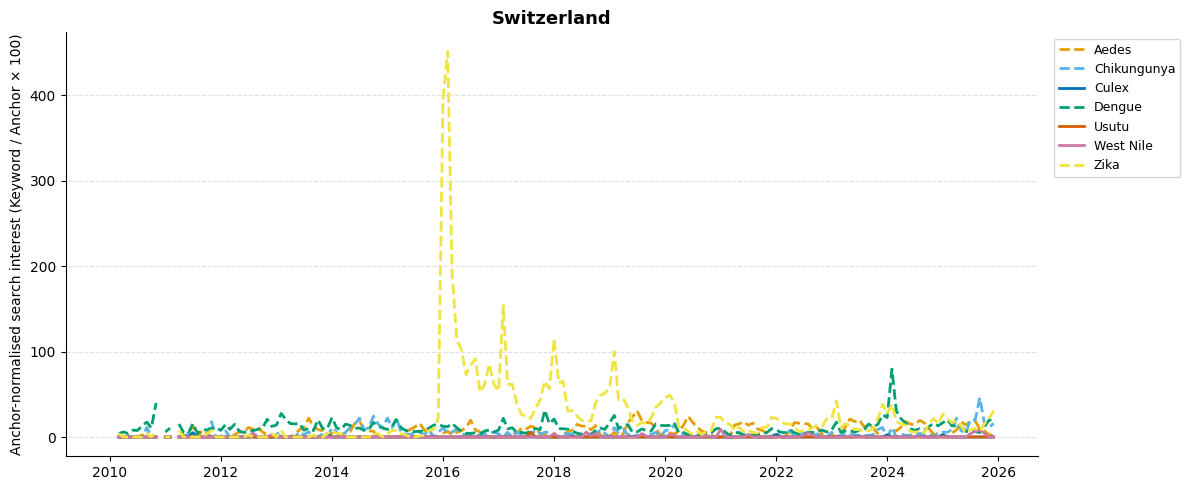

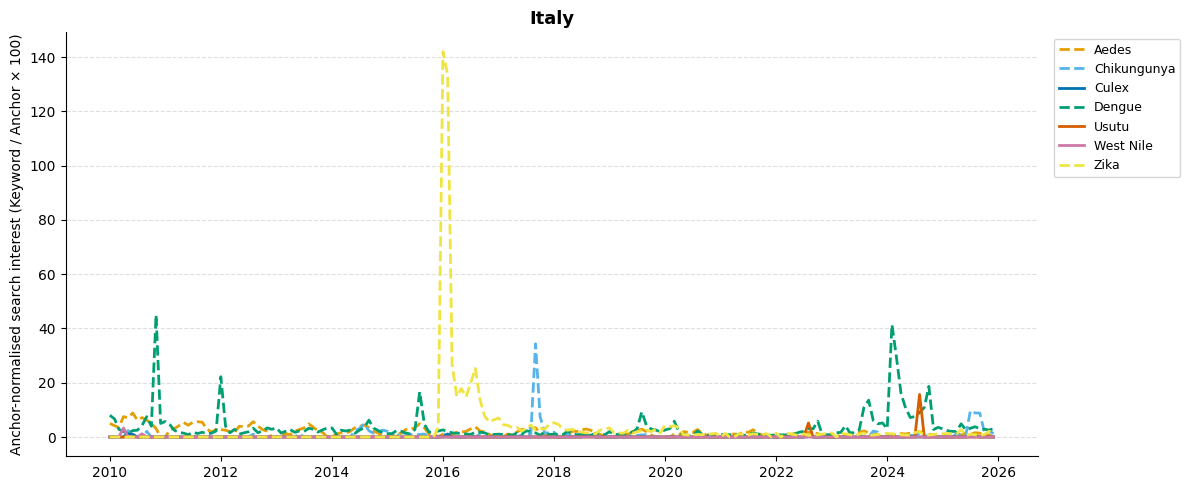

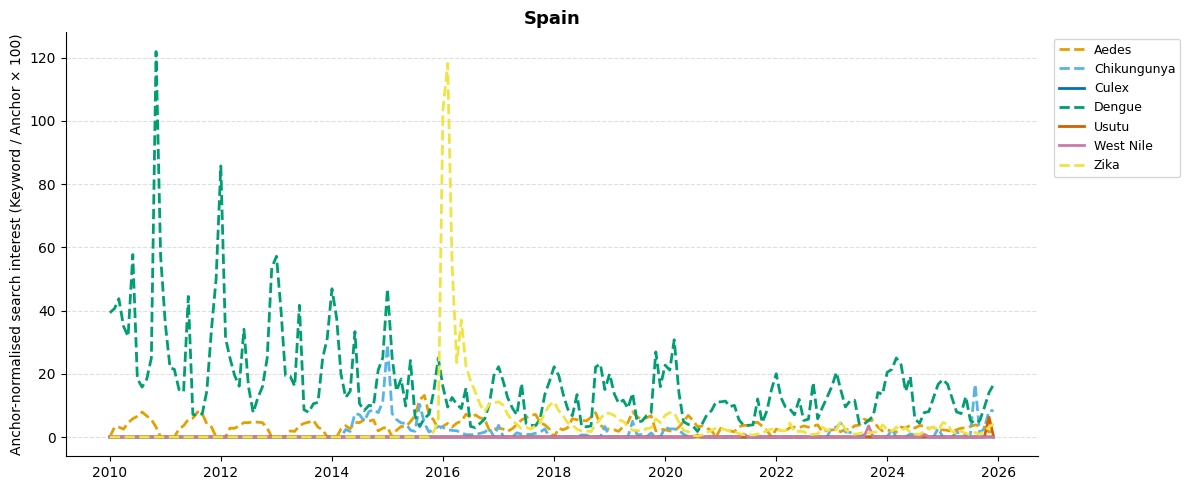

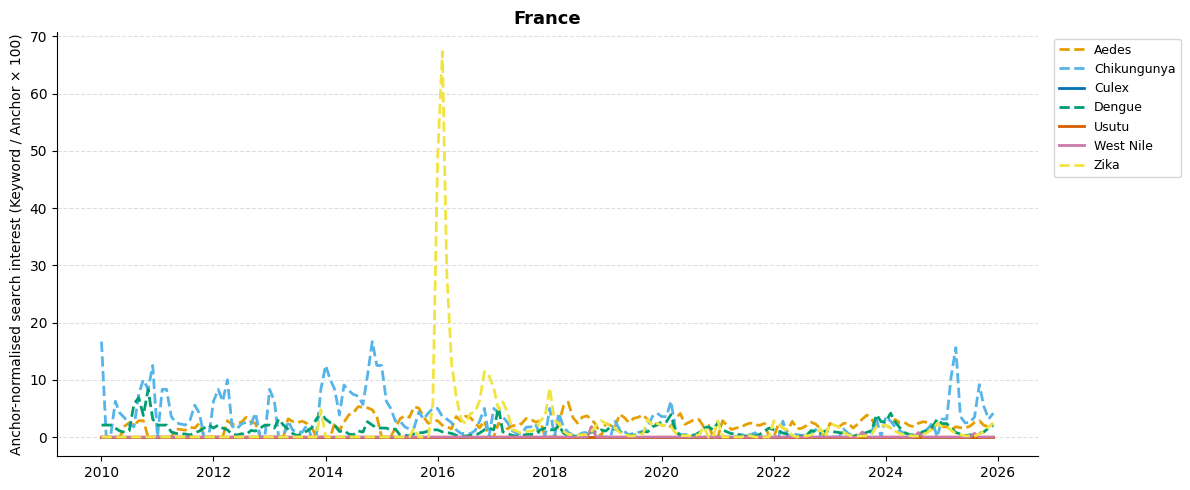

In [ ]:
subtype_to_system = {v["Sub-type"]: v["System"] for v in meta.values()}

for geo in COUNTRY_ORDER:
     if geo not in subtype_means:
         continue
     fig_c, ax = plt.subplots(figsize=(12, 5))
     for subtype, series in subtype_means[geo].items():
         colour    = SUBTYPE_COLOURS.get(subtype, "#888888")
         system    = subtype_to_system.get(subtype, "")
         linestyle = SYSTEM_STYLES.get(system, "solid")
         smoothed  = series.rolling(3, center=True, min_periods=1).mean()
         ax.plot(series.index, series.values, # change to smoothed. for 3 month rolling average
                 color=colour, linewidth=2, linestyle=linestyle, label=subtype)
     ax.set_title(f"{COUNTRY_LABELS.get(geo, geo)}",
                  fontsize=13, fontweight="bold")
     ax.set_ylabel("Anchor-normalised search interest (Keyword / Anchor × 100)")
     ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
     ax.xaxis.set_major_locator(mdates.YearLocator(2))
     ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
     ax.grid(axis="y", linestyle="--", alpha=0.4)
     ax.spines[["top", "right"]].set_visible(False)
     plt.tight_layout()
     fig_c.savefig(OUTPUT_PATH / f"trends_{geo}.png", dpi=150, bbox_inches="tight")
     plt.show()

## 8. Per system average (system-resolution) 

Sub-types have been averaged to give a system-wide perspective. Could change to weighted mean for full analysis.

In [15]:
# ── Build keyword → system lookup ─────────────────────────────────────────────
SUBTYPE_TO_SYSTEM: dict[str, str] = {
    v["Sub-type"]: v["System"] for v in meta.values()
}

# Invert to keyword → system
KEYWORD_TO_SYSTEM: dict[str, str] = {
    kw: SUBTYPE_TO_SYSTEM[v["Sub-type"]]
    for kw, v in meta.items()
}

# ── Aggregate system means directly from keyword-level data ───────────────────
system_data: dict[str, dict[str, pd.Series]] = {}

for geo, df in country_data.items():

    system_data[geo] = {}

    for system in SYSTEM_STYLES:  # preserves order

        # select keywords belonging to this system
        cols = [
            kw for kw in df.columns
            if kw in KEYWORD_TO_SYSTEM and KEYWORD_TO_SYSTEM[kw] == system
        ]

        if not cols:
            continue

        # direct system-wide average (NO z-scores)
        system_data[geo][system] = df[cols].mean(axis=1)

print("Systems aggregated per country:")
for geo, systems in system_data.items():
    print(f"  {geo}: {list(systems.keys())}")

Systems aggregated per country:
  DE: ['Aedes-borne disease system', 'Culex-borne disease system']
  AT: ['Aedes-borne disease system', 'Culex-borne disease system']
  CH: ['Aedes-borne disease system', 'Culex-borne disease system']
  IT: ['Aedes-borne disease system', 'Culex-borne disease system']
  ES: ['Aedes-borne disease system', 'Culex-borne disease system']
  FR: ['Aedes-borne disease system', 'Culex-borne disease system']


Anchor currently enabled.

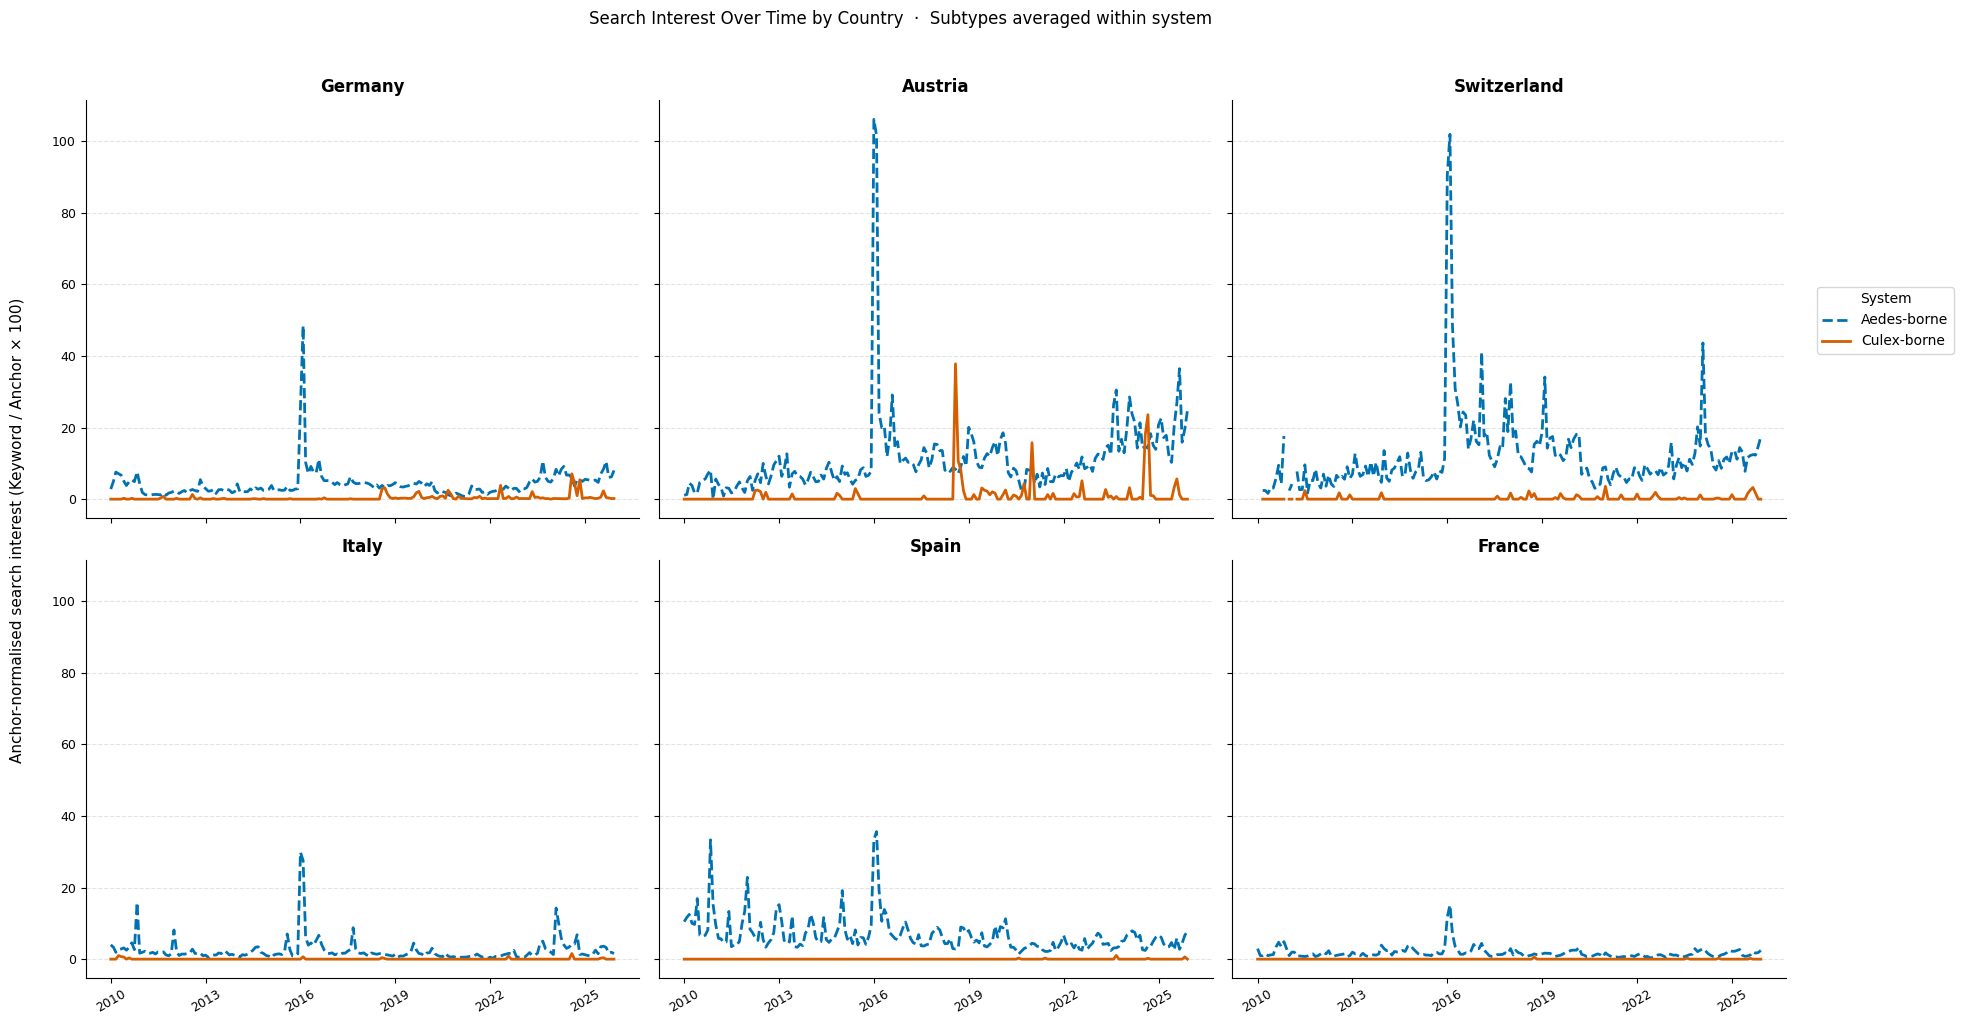

Saved → trends_timeseries_systems.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)

for ax, geo in zip(axes.flatten(), COUNTRY_ORDER):
    if geo not in system_data:
        ax.set_visible(False)
        continue

    for system, series in system_data[geo].items():
        linestyle = SYSTEM_STYLES.get(system, "solid")
        colour    = SYSTEM_COLOURS.get(system, "#888888")
        smoothed  = series.rolling(3, center=True, min_periods=1).mean()

        # Faint raw monthly line
        ax.plot(series.index, series.values,
                color=colour, #alpha=0.15, linewidth=0.7, 
                linewidth=2, linestyle=linestyle,
                label=system.replace(" disease system", ""))
        # Bold 3-month rolling average
        #ax.plot(smoothed.index, smoothed.values,
                #color=colour, linewidth=2, linestyle=linestyle,
                #label=system.replace(" disease system", ""))

    # ── Anchor line (black) ──────────────────────────────────
    if geo in anchor_series:
        anc          = anchor_series[geo]
        anc_smoothed = anc.rolling(3, center=True, min_periods=1).mean()
        ax.plot(anc.index, anc.values,
                color="black", #alpha=0.15, linewidth=0.7, 
                linewidth=2, linestyle="solid", label="Anchor")
        #ax.plot(anc_smoothed.index, anc_smoothed.values,
                #color="grey", linewidth=2, linestyle="dotted", label="Anchor")

    ax.set_title(COUNTRY_LABELS.get(geo, geo), fontsize=12, fontweight="bold")
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

# ── Single shared legend ──────────────────────────────────────────────────────
handles = [
    mlines.Line2D([], [], color=SYSTEM_COLOURS.get(sys, "#888888"),
                  linewidth=2, linestyle=ls,
                  label=sys.replace(" disease system", ""))
    for sys, ls in SYSTEM_STYLES.items()
] + [
    mlines.Line2D([], [], color="black", linewidth=2, linestyle="solid",
                  label="Anchor (mosquito term)")
]
fig.legend(handles=handles, title="System", fontsize=10,
           loc="upper left", bbox_to_anchor=(1.005, 0.75), frameon=True)

fig.text(0.005, 0.5, "Anchor-normalised search interest (Keyword / Anchor × 100)",
         va="center", rotation="vertical", fontsize=11)
fig.suptitle(
    "Search Interest Over Time by Country  ·  Subtypes averaged within system",
    fontsize=12, y=1.02,
)

plt.tight_layout(rect=[0.02, 0, 1, 1])
out = OUTPUT_PATH / "trends_timeseries_systems.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## 10. Monthly time-series plots per country and subtype

In [12]:
subtype_means = pd.read_csv("trends_subtype_means.csv", index_col=0)

C:\Users\annab\AppData\Local\Temp\ipykernel_56188\6570971.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


Chart saved → GoogleTrends_monthly_timeseries_DE.png


C:\Users\annab\AppData\Local\Temp\ipykernel_56188\6570971.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


Chart saved → GoogleTrends_monthly_timeseries_AT.png


C:\Users\annab\AppData\Local\Temp\ipykernel_56188\6570971.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


...

Chart saved → GoogleTrends_monthly_timeseries_IT.png


C:\Users\annab\AppData\Local\Temp\ipykernel_56188\6570971.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


Chart saved → GoogleTrends_monthly_timeseries_ES.png


C:\Users\annab\AppData\Local\Temp\ipykernel_56188\6570971.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


Chart saved → GoogleTrends_monthly_timeseries_FR.png
Zika chart saved → GoogleTrends_zika_by_country.png


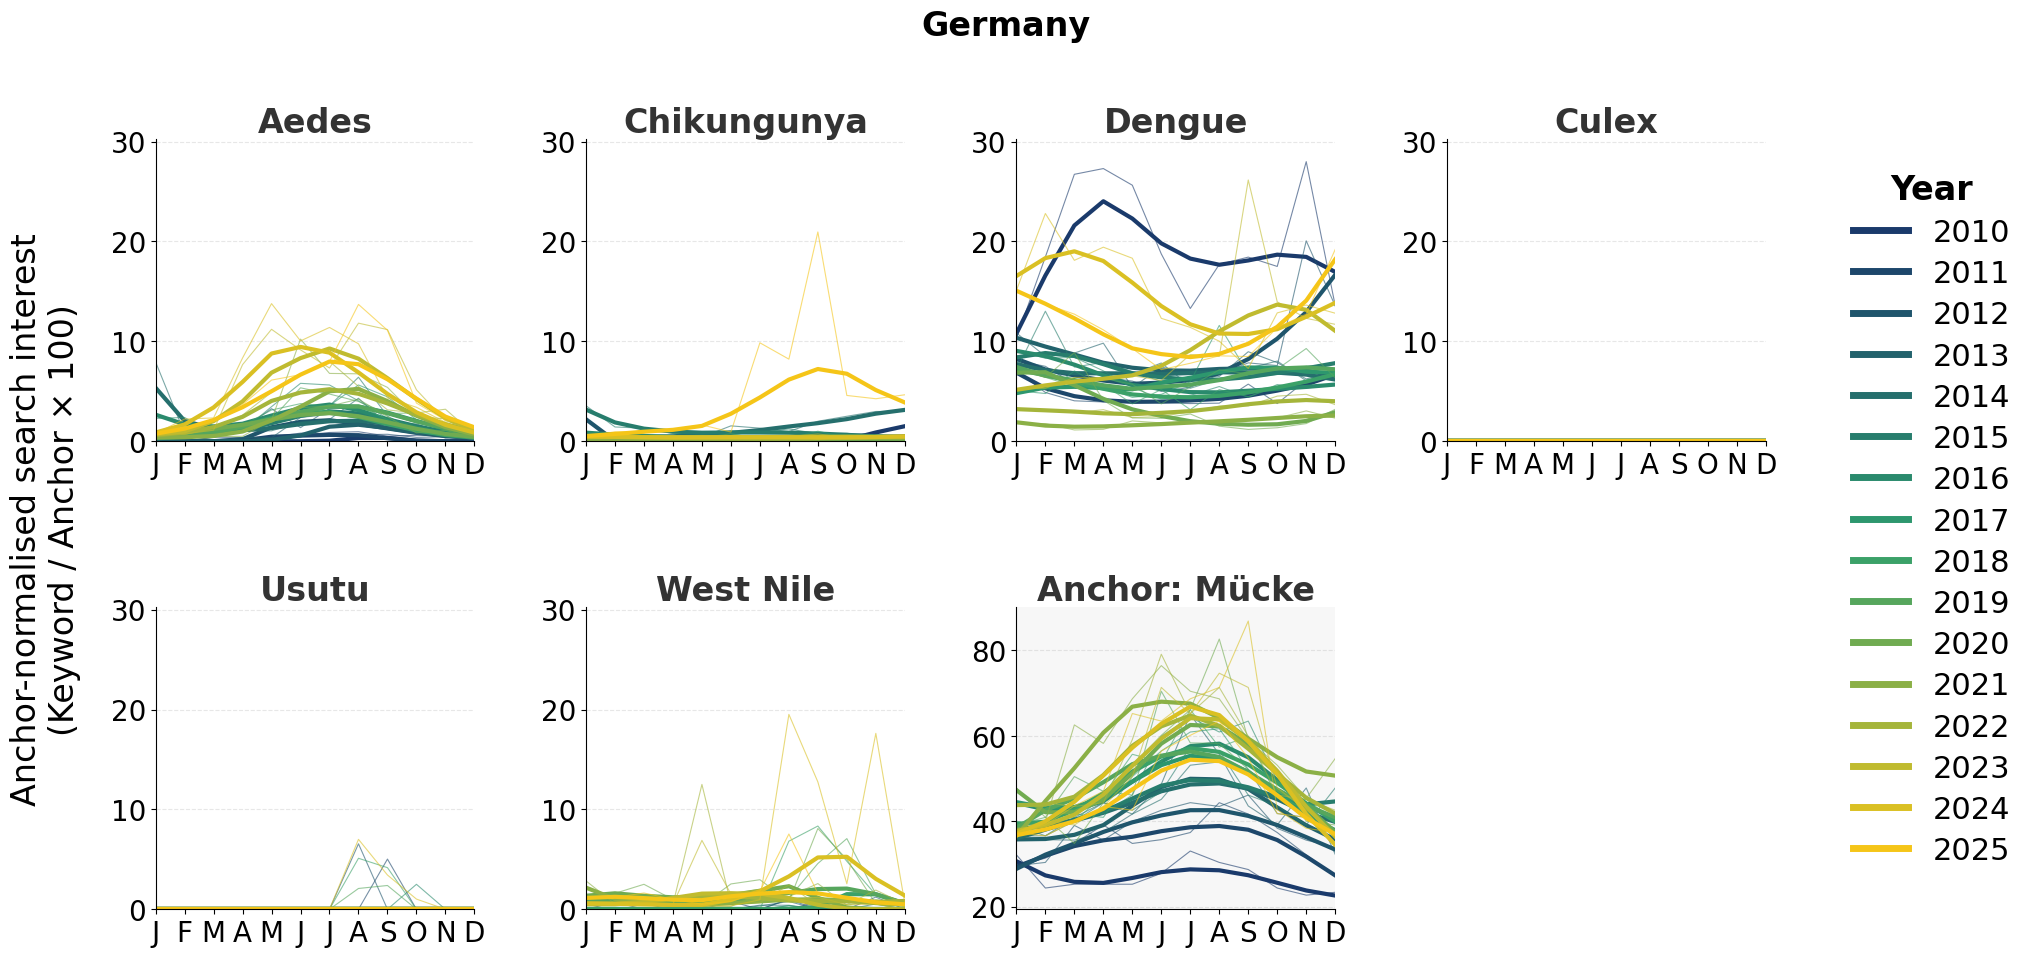

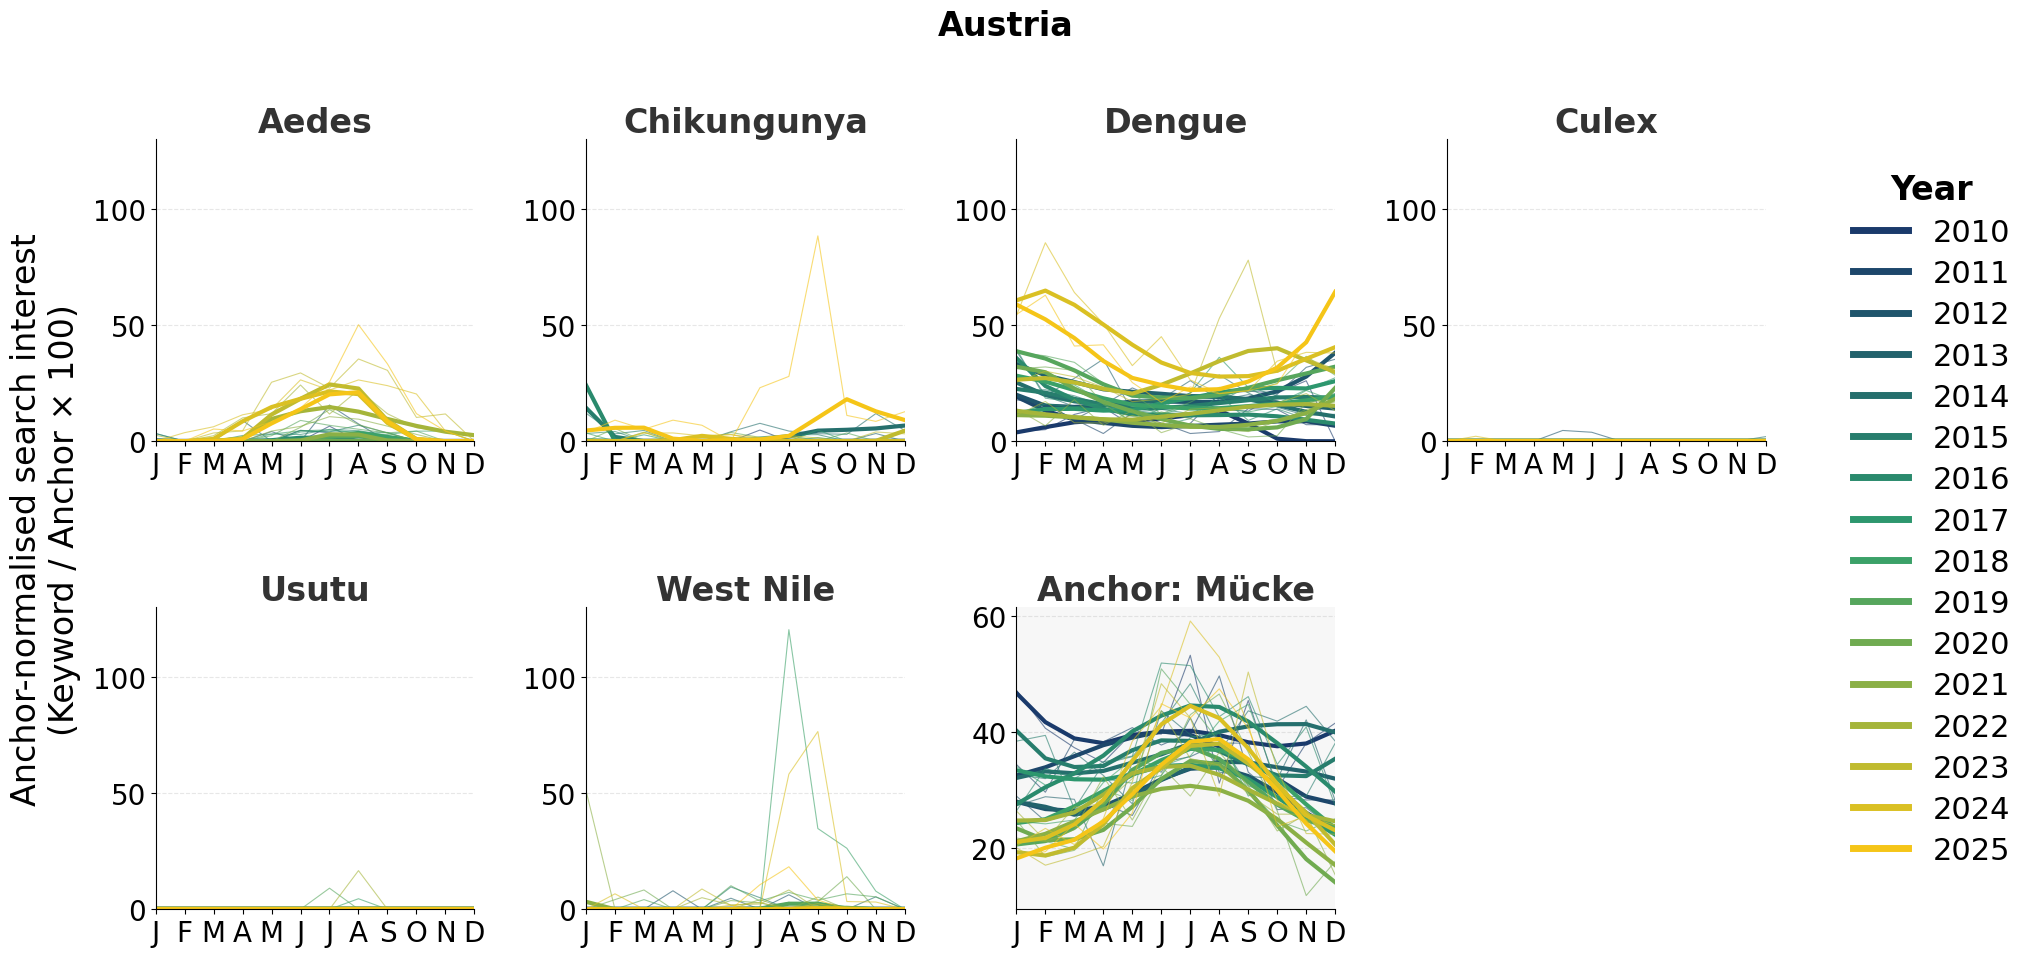

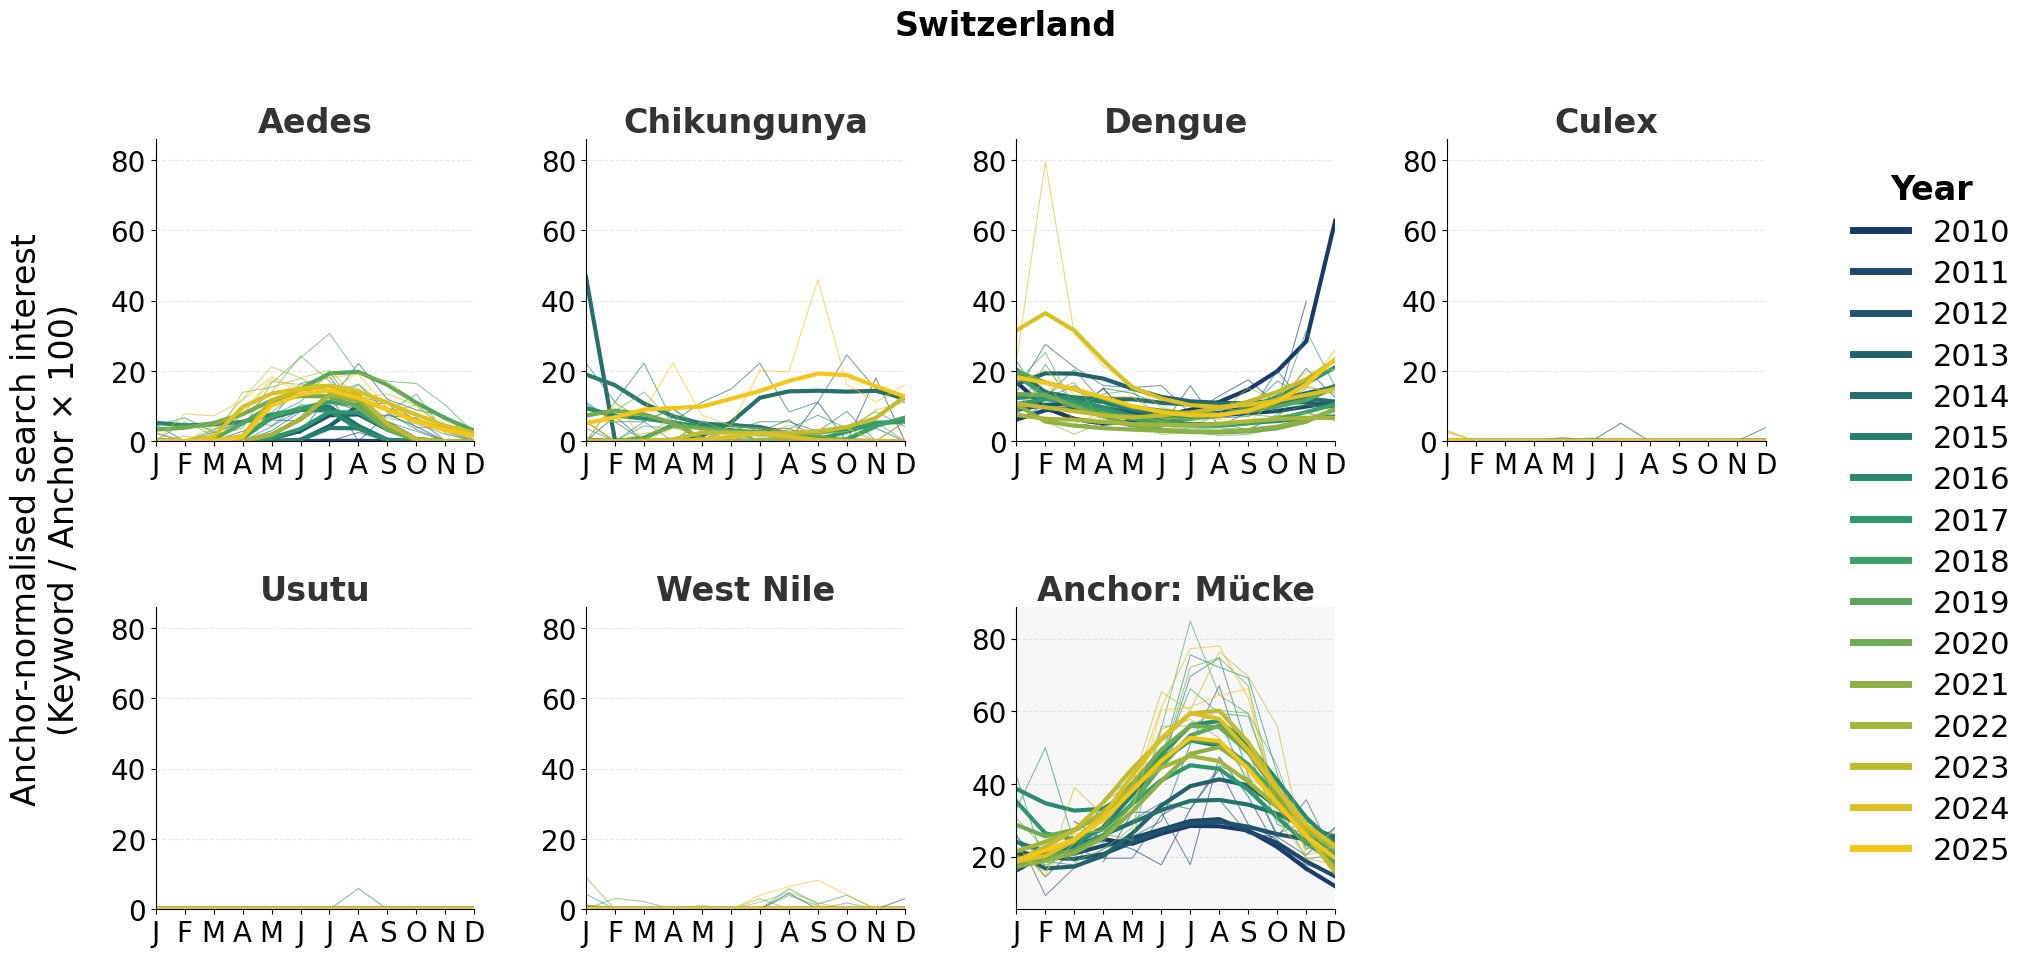

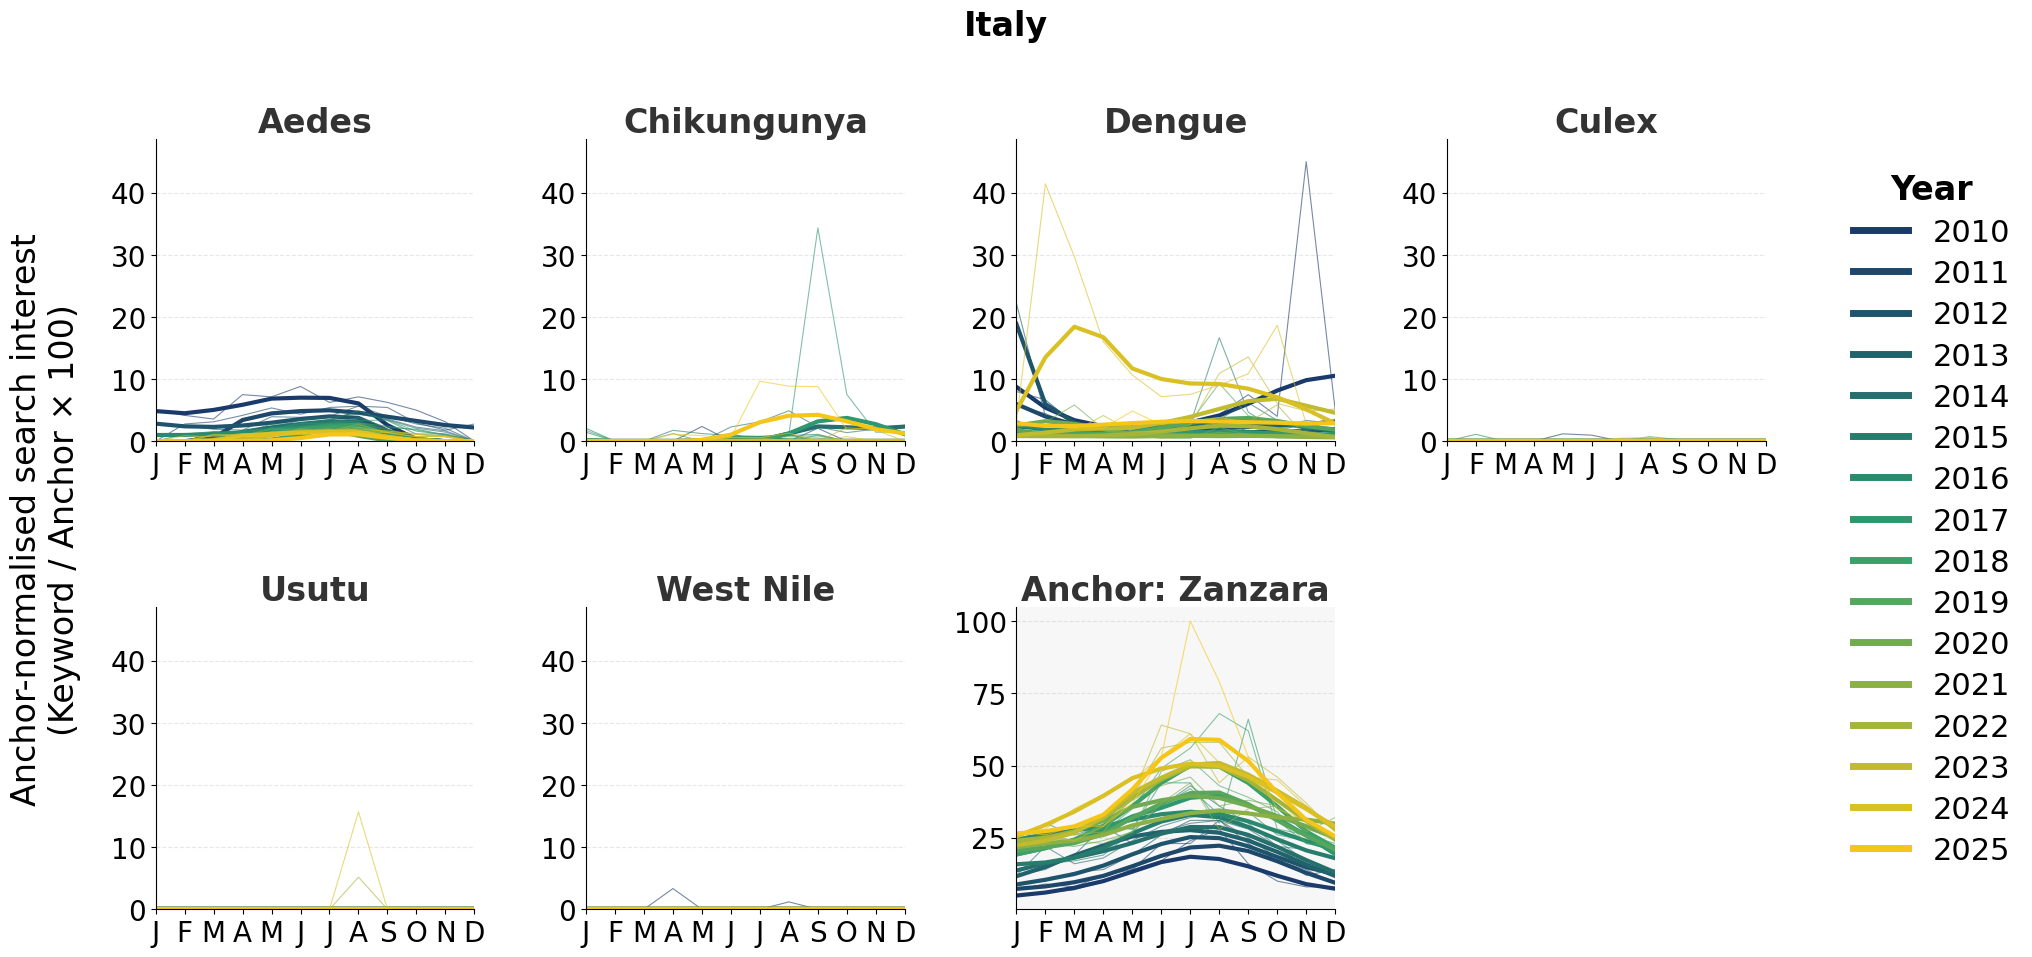

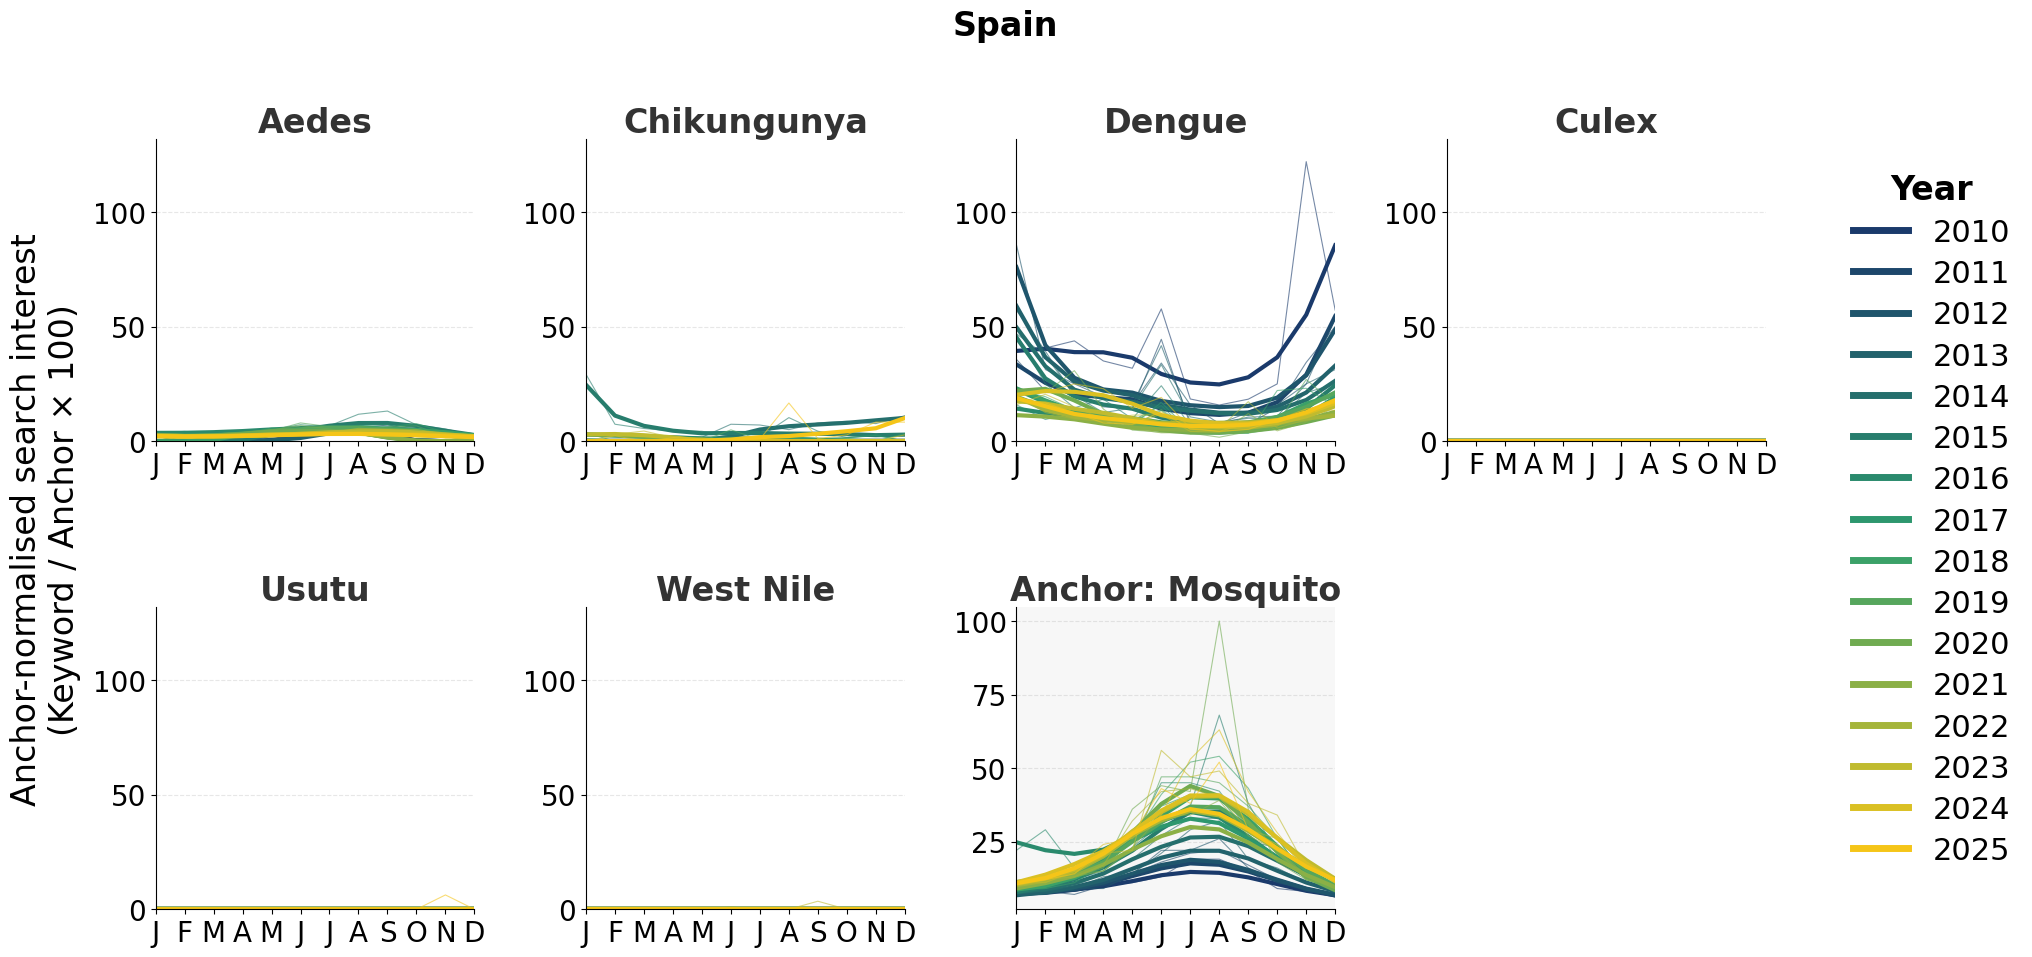

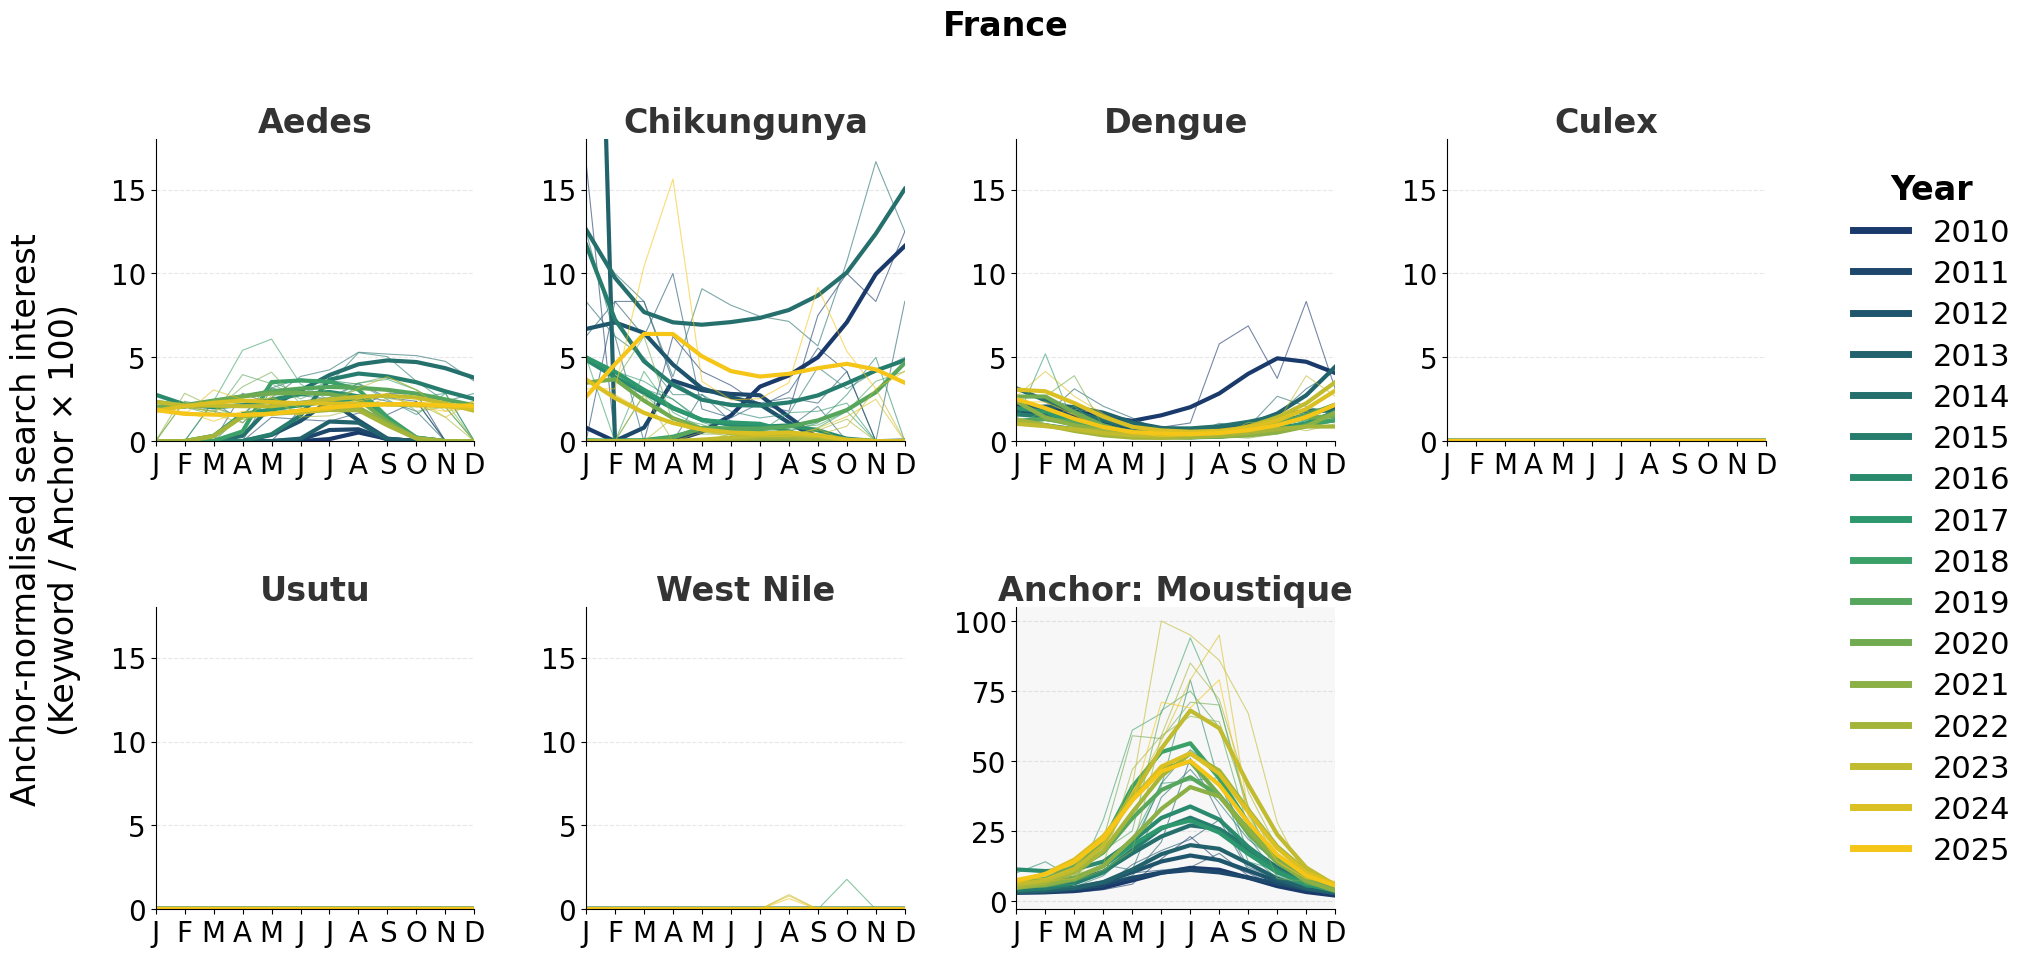

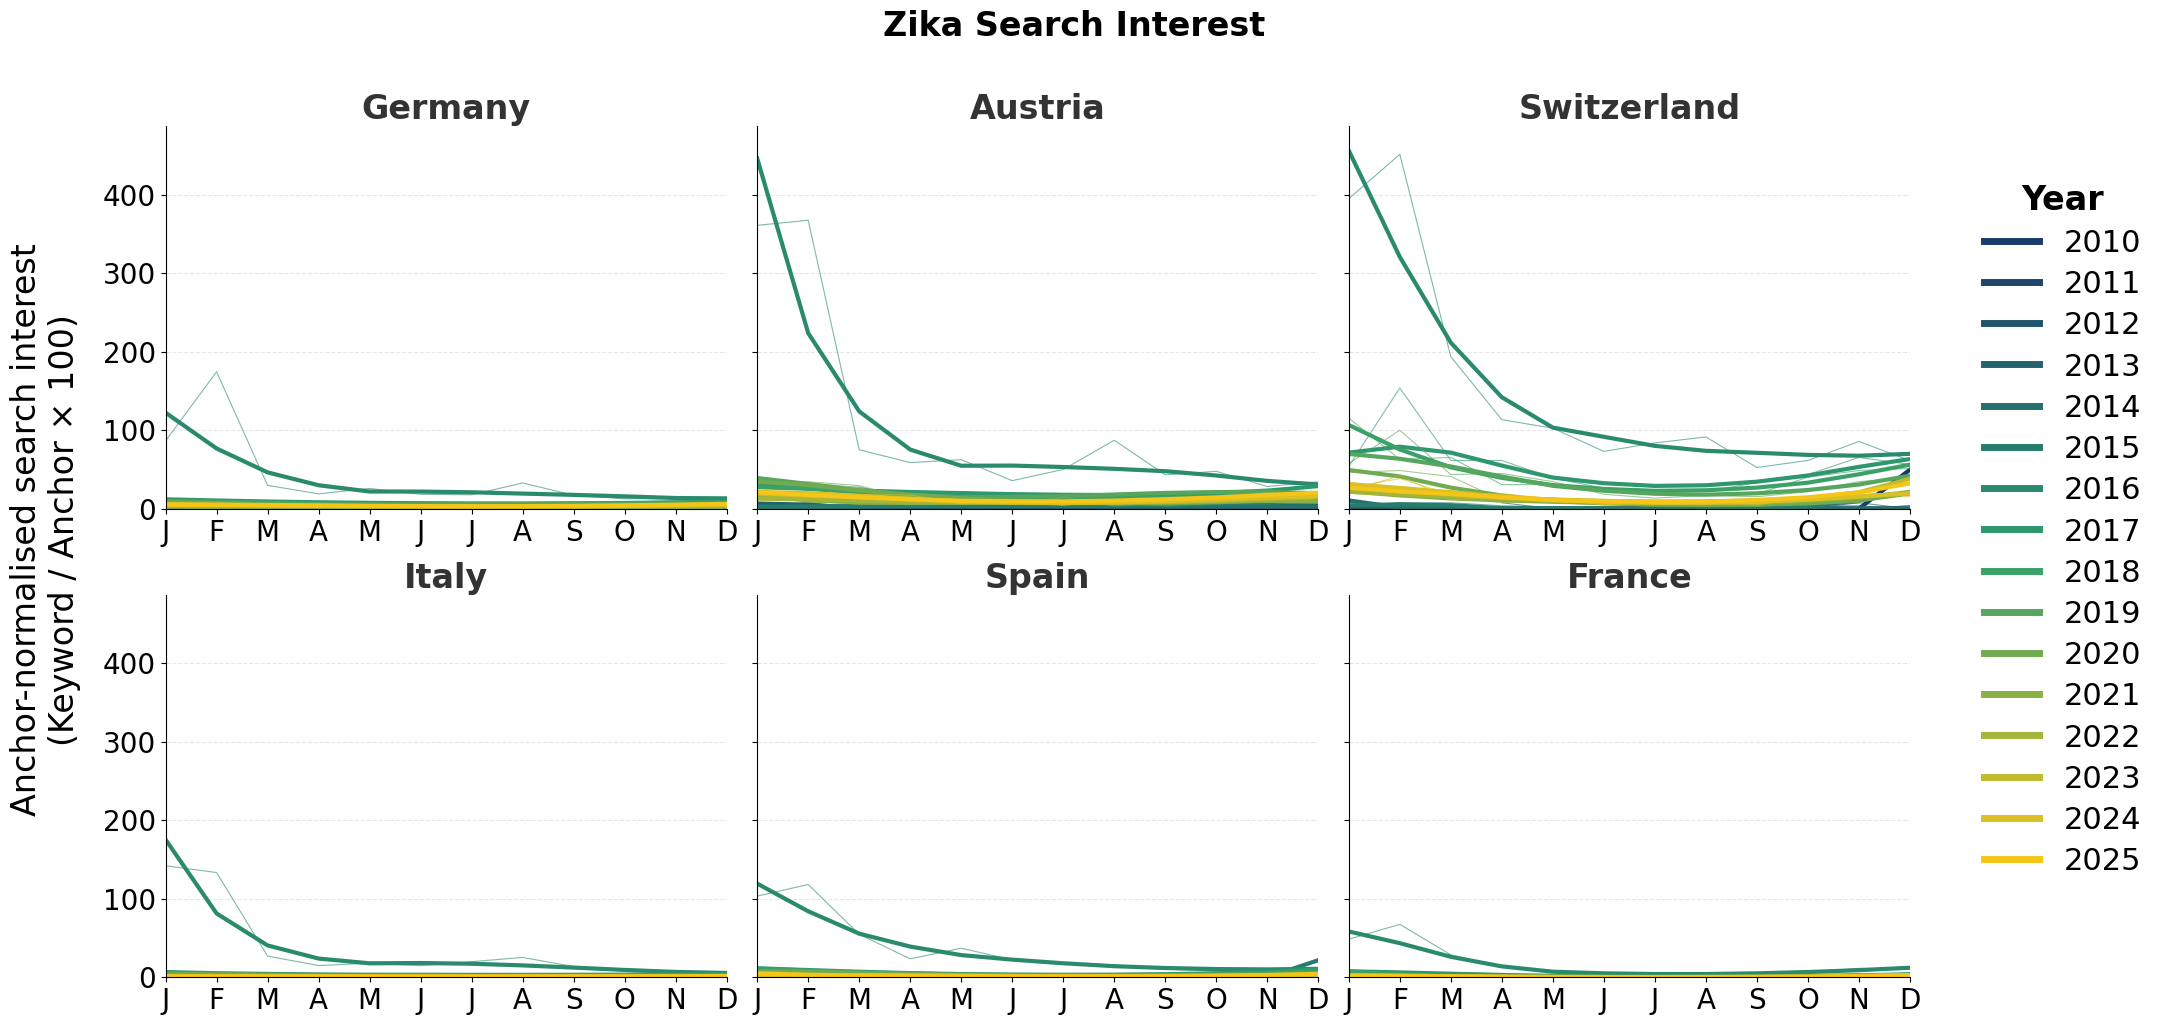

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LOESS helper  (no statsmodels dependency — pure numpy)
# ─────────────────────────────────────────────────────────────────────────────

def _loess(
    x: np.ndarray,
    y: np.ndarray,
    frac: float = 0.5,
    eps: float = 1e-6,
) -> np.ndarray:
    """
    Positivity-preserving LOESS.

    Fits the local regression on log(y + eps) and exponentiates the
    prediction, guaranteeing strictly positive fitted values.
    """
    n = len(x)
    out = np.full(n, np.nan)

    finite = np.isfinite(y)
    if finite.sum() < 3:
        return out

    half_window = max(int(np.ceil(frac * n / 2)), 2)

    for i in range(n):
        lo = max(0, i - half_window)
        hi = min(n, i + half_window)

        xi = x[lo:hi]
        yi = y[lo:hi]

        mask = np.isfinite(yi)
        if mask.sum() < 2:
            continue

        xi = xi[mask]
        yi = yi[mask]

        log_y = np.log(np.maximum(yi, 0) + eps)

        d = np.abs(xi - x[i])
        max_d = d.max()
        if max_d == 0:
            max_d = 1.0

        w = (1 - (d / max_d) ** 3) ** 3

        A = np.column_stack((np.ones_like(xi), xi))
        Aw = A * w[:, None]
        yw = log_y * w

        try:
            coef = np.linalg.lstsq(Aw, yw, rcond=None)[0]
            pred_log = coef[0] + coef[1] * x[i]
            out[i] = np.exp(pred_log)
        except np.linalg.LinAlgError:
            pass

    return out


# ─────────────────────────────────────────────────────────────────────────────
# CUSTOM 3-STOP COLORMAP  (dark-blue → green → yellow, colourblind-safe)
# ─────────────────────────────────────────────────────────────────────────────

_GRADIENT_COLOURS = [
    "#1a3a6b",   # dark navy-blue  (early years)
    "#2e9e6e",   # teal-green      (middle years)
    "#f5c518",   # warm yellow     (recent years)
]
YEAR_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "blue_green_yellow", _GRADIENT_COLOURS
)


# ─────────────────────────────────────────────────────────────────────────────
# SHARED PANEL-DRAWING HELPER
# ─────────────────────────────────────────────────────────────────────────────

def _draw_series_panel(
    ax,
    series: pd.Series,
    year_colour: dict,
    loess_frac: float,
    y_lim: tuple | None = None,
    title: str = "",
    title_colour: str = "#333333",
    facecolor: str | None = None,
    month_labels: list | None = None,
):
    """Draw one sub-panel: faint raw lines + bold LOESS lines, one per year."""
    if month_labels is None:
        month_labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]

    if facecolor:
        ax.set_facecolor(facecolor)

    for yr, yr_series in series.groupby(series.index.year):
        monthly = pd.Series(np.nan, index=range(1, 13), dtype=float)
        monthly.update(yr_series.set_axis(yr_series.index.month))
        colour = year_colour.get(yr, "grey")
        x_arr  = monthly.index.to_numpy(dtype=float)
        y_arr  = monthly.values.astype(float)

        ax.plot(x_arr, y_arr, color=colour, linewidth=0.8, alpha=0.6)
        smoothed = _loess(x_arr, y_arr, frac=loess_frac)
        ax.plot(x_arr, smoothed, color=colour, linewidth=3.0, alpha=1)

    ax.set_title(title, fontsize=24, fontweight="bold", color=title_colour, pad=4)  # changed: 18 → 24
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=20, ha="center")  # changed: 16 → 20, added ha="center"
    ax.set_xlim(1, 12)
    ax.tick_params(axis="y", labelsize=20)  # changed: 7 → 20
    ax.margins(x=0)  # added: removes gap between y-axis and plot data
    if y_lim:
        ax.set_ylim(*y_lim)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)


def _add_year_legend(fig, norm, years_sorted, right_x=0.91):
    """
    Discrete line-swatch legend (one coloured entry per year) placed on the
    right margin — same style as the reference image.
    """
    handles = [
        mlines.Line2D(
            [], [],
            color=YEAR_CMAP(norm(yr)),
            linewidth=5,
            label=str(yr),
        )
        for yr in years_sorted
    ]
    leg = fig.legend(
        handles=handles,
        title="Year",
        title_fontsize=24,  # changed: 18 → 20
        fontsize=22,        # changed: 18 → 20
        loc="center left",
        bbox_to_anchor=(right_x, 0.5),
        frameon=False,
        handlelength=1.8,
        handleheight=0.8,
        labelspacing=0.4,
    )
    leg.get_title().set_fontweight("bold")


# ─────────────────────────────────────────────────────────────────────────────
# COUNTRY FIGURES  (Zika excluded)
# ─────────────────────────────────────────────────────────────────────────────

def plot_timeseries(
    df: pd.DataFrame,
    meta: dict,
    anchor_series: dict | None = None,
    save_path: Path | None = None,
    loess_frac: float = 0.7,
    zika_subtype: str = "Zika",
) -> list[plt.Figure]:
    """
    One figure per country, 4×2 grid of sub-panels.
    Zika is excluded from these panels; call plot_zika_figure() separately.

    Panels (in order): non-Zika subtypes, then anchor (if provided), then empty.
    """
    MONTH_LABELS = ["J","F","M","A","M","J","J","A","S","O","N","D"]
    N_COLS, N_ROWS = 4, 2
    MAX_PANELS = N_COLS * N_ROWS

    df = df.copy()
    df.index = pd.to_datetime(df.index)

    col_tuples   = [c.split("::") for c in df.columns]
    all_geos     = list(dict.fromkeys(t[0] for t in col_tuples))
    all_subtypes = list(dict.fromkeys(t[1] for t in col_tuples))

    countries = [g for g in COUNTRY_ORDER if g in all_geos] or all_geos

    subtypes_order = [s for s in SUBTYPE_COLOURS if s in all_subtypes]
    subtypes_order += [s for s in all_subtypes if s not in subtypes_order]

    # Remove Zika from per-country panels
    subtypes_order = [s for s in subtypes_order if s != zika_subtype]

    years_sorted = sorted(df.index.year.unique())
    year_min, year_max = years_sorted[0], years_sorted[-1]
    norm        = mcolors.Normalize(vmin=year_min, vmax=year_max)
    year_colour = {yr: YEAR_CMAP(norm(yr)) for yr in years_sorted}

    figures = []

    for geo in countries:
        geo_cols = {t[1]: f"{geo}::{t[1]}" for t in col_tuples if t[0] == geo}
        subtypes_present = [s for s in subtypes_order if s in geo_cols]

        has_anchor = anchor_series is not None and geo in anchor_series
        n_subtype_slots = MAX_PANELS - (1 if has_anchor else 0)
        subtypes_show = subtypes_present[:n_subtype_slots]

        panel_list = subtypes_show[:]
        if has_anchor:
            panel_list.append("__anchor__")
        panel_list += [None] * (MAX_PANELS - len(panel_list))

        try:
            country_label = COUNTRY_LABELS.get(geo, geo)
        except NameError:
            country_label = geo

        fig = plt.figure(figsize=(20, 10))
        fig.suptitle(
            f"{country_label}",
            fontsize=24, fontweight="bold", y=1.01,  # unchanged: already 24
        )

        outer = gridspec.GridSpec(
            N_ROWS, N_COLS, figure=fig,
            hspace=0.55, wspace=0.35, right=0.88, left=0.075,
        )

        # Shared y-range: exclude Zika columns so scale isn't distorted
        non_zika_cols = [
            c for c in df.columns
            if c.startswith(f"{geo}::") and not c.endswith(f"::{zika_subtype}")
        ]
        country_data = df[non_zika_cols] if non_zika_cols else df[
            [c for c in df.columns if c.startswith(f"{geo}::")]
        ]
        y_max = np.nanmax(country_data.values)
        y_pad = y_max * 0.08 or 1
        y_lim = (0, y_max + y_pad)

        for idx, panel in enumerate(panel_list):
            row, col = divmod(idx, N_COLS)
            ax = fig.add_subplot(outer[row, col])

            if panel is None:
                ax.set_visible(False)
                continue

            if panel == "__anchor__":
                anc = anchor_series[geo].copy()
                anc.index = pd.to_datetime(anc.index)
                try:
                    anchor_word = ANCHOR_PER_COUNTRY.get(geo, "anchor")
                except NameError:
                    anchor_word = "anchor"
                _draw_series_panel(
                    ax, anc, year_colour, loess_frac,
                    y_lim=None,
                    title=f"Anchor: {anchor_word}",
                    facecolor="#f7f7f7",
                    month_labels=MONTH_LABELS,
                )
                continue

            series = df[geo_cols[panel]]

            _draw_series_panel(
                ax, series, year_colour, loess_frac,
                y_lim=y_lim,
                title=panel,
                month_labels=MONTH_LABELS,
            )

        fig.supylabel(
            "Anchor-normalised search interest\n(Keyword / Anchor × 100)",
            fontsize=24, ha="center",
        )

        _add_year_legend(fig, norm, years_sorted)
        plt.tight_layout(rect=[0.03, 0, 0.90, 1])

        if save_path:
            out = save_path.parent / f"{save_path.stem}_{geo}{save_path.suffix}"
            fig.savefig(out, dpi=150, bbox_inches="tight")
            print(f"Chart saved → {out}")

        figures.append(fig)

    return figures


# ─────────────────────────────────────────────────────────────────────────────
# ZIKA FIGURE  (one panel per country, all on one figure)
# ─────────────────────────────────────────────────────────────────────────────

def plot_zika_figure(
    df: pd.DataFrame,
    meta: dict | None = None,
    save_path: Path | None = None,
    loess_frac: float = 0.7,
    zika_subtype: str = "Zika",
) -> plt.Figure:
    """
    Single figure with one panel per country showing Zika search interest.
    Layout: up to 3 columns, rows as needed.
    Lines = years (same blue→green→yellow gradient as the country figures).
    """
    MONTH_LABELS = ["J","F","M","A","M","J","J","A","S","O","N","D"]

    df = df.copy()
    df.index = pd.to_datetime(df.index)

    col_tuples = [c.split("::") for c in df.columns]
    all_geos   = list(dict.fromkeys(t[0] for t in col_tuples))

    try:
        countries = [g for g in COUNTRY_ORDER if g in all_geos] or all_geos
    except NameError:
        countries = all_geos

    zika_cols = {
        geo: f"{geo}::{zika_subtype}"
        for geo in countries
        if f"{geo}::{zika_subtype}" in df.columns
    }
    countries_with_zika = [g for g in countries if g in zika_cols]

    if not countries_with_zika:
        print("[warn] No Zika columns found in DataFrame.")
        return plt.figure()

    years_sorted = sorted(df.index.year.unique())
    year_min, year_max = years_sorted[0], years_sorted[-1]
    norm        = mcolors.Normalize(vmin=year_min, vmax=year_max)
    year_colour = {yr: YEAR_CMAP(norm(yr)) for yr in years_sorted}

    n     = len(countries_with_zika)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7 * ncols, 5 * nrows),
        sharey=True,
        squeeze=False,
    )
    axes_flat = axes.flatten()

    zika_values = df[[v for v in zika_cols.values()]].values
    y_max = np.nanmax(zika_values)
    y_pad = y_max * 0.08 or 1
    y_lim = (0, y_max + y_pad)

    for i, geo in enumerate(countries_with_zika):
        ax = axes_flat[i]
        series = df[zika_cols[geo]]

        try:
            country_label = COUNTRY_LABELS.get(geo, geo)
        except NameError:
            country_label = geo

        _draw_series_panel(
            ax, series, year_colour, loess_frac,
            y_lim=y_lim,
            title=country_label,
            month_labels=MONTH_LABELS,
        )

    for ax in axes_flat[len(countries_with_zika):]:
        ax.set_visible(False)

    fig.suptitle(
        "Zika Search Interest",
        fontsize=24, fontweight="bold", y=1.02,  # unchanged: already 24
    )
    fig.text(
        0.01, 0.5,
        "Anchor-normalised search interest\n(Keyword / Anchor × 100)",
        va="center", ha="center",  # added: ha="center"
        rotation="vertical", fontsize=24,  # changed: 18 → 20
    )

    _add_year_legend(fig, norm, years_sorted, right_x=0.92)
    plt.tight_layout(rect=[0.03, 0, 0.91, 1])

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Zika chart saved → {save_path}")

    return fig


# ─────────────────────────────────────────────────────────────────────────────
# USAGE
# ─────────────────────────────────────────────────────────────────────────────

figs = plot_timeseries(
    subtype_means, meta,
    anchor_series=anchor_series,
    save_path=OUTPUT_PATH / "GoogleTrends_monthly_timeseries.png",
)

fig_zika = plot_zika_figure(
    subtype_means, meta,
    save_path=OUTPUT_PATH / "GoogleTrends_zika_by_country.png",
)

plt.show()